# E-commerce Sales & Profitability Analysis

## Business Problem

The objective of this analysis is to evaluate e-commerce sales and
profitability performance and identify the customers, products,
categories, regions and sales practices that are contributing to
or negatively affecting business performance.

## Key Business Questions

1. What are the company's overall sales and profitability levels?
2. How have sales and profit changed over time?
3. Which categories and products contribute most to revenue and profit?
4. Which customers and customer segments generate the most value?
5. Which regions perform best and which require attention?
6. Is discounting associated with lower profitability?
7. Are there products generating high sales but weak or negative profit?
8. What actions could management take based on these findings?

In [1]:
# Import the required libraries
import pandas as pd
import openpyxl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print("Pandas:", pd.__version__)
print("Excel support: OK")

Pandas: 2.2.2
Excel support: OK


In [2]:
# Load dataset and display the first few rows to check the dataset
df = pd.read_excel("data/Excel raw data.xlsx")  
df.head()  

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.info()  # Display information about the dataset, including data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [4]:
df.describe()  # Display summary statistics for numerical columns in the dataset

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [5]:
df.shape  # Display the shape of the dataset (number of rows and columns)

(9994, 21)

In [6]:
# Checking for missing values in the dataset
missing_values=df.isnull().sum()
missing_values

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
# checking for duplicates
duplicate_count=df.duplicated().sum()
duplicate_count

0

In [8]:
# Display the data types of each column in the dataset
df.dtypes


Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nDate range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

print("\nCategories:")
print(df["Category"].unique())

print("\nSegments:")
print(df["Segment"].unique())

print("\nRegions:")
print(df["Region"].unique())

Rows: 9994
Columns: 21

Date range:
2014-01-03 00:00:00 to 2017-12-30 00:00:00

Categories:
['Furniture' 'Office Supplies' 'Technology']

Segments:
['Consumer' 'Corporate' 'Home Office']

Regions:
['South' 'West' 'Central' 'East']


### Key Analytical Fields

- Sales → revenue generated from an order line
- Quantity → units sold
- Discount → discount applied to the order line
- Profit → profit generated
- Category / Sub-Category → product hierarchy
- Segment → customer type
- Region → geographic performance
- Order Date → time-series analysis

The dataset contains no missing values or duplicated values and is therefore clean for further analysis.

### Checking for Data Qualty Issues

In [10]:

(df["Profit"]<0).sum()  # Count the number of negative profit values in the dataset   

1871

The data shows presence of negative profit implying losses so I need to check the columns to be sure that negative profits do exist indeed

In [11]:
negative_profit=df[df["Profit"]<0]
negative_profit

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
14,15,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5,0.80,-123.8580
15,16,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-BI-10000756,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,3,0.80,-3.8160
23,24,US-2017-156909,2017-07-16,2017-07-18,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,19140,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9920,9921,CA-2016-149272,2016-03-15,2016-03-19,Standard Class,MY-18295,Muhammed Yedwab,Corporate,United States,Bryan,...,77803,Central,OFF-BI-10004233,Office Supplies,Binders,"GBC Pre-Punched Binding Paper, Plastic, White,...",22.3860,7,0.80,-35.8176
9921,9922,CA-2014-111360,2014-11-24,2014-11-30,Standard Class,AT-10435,Alyssa Tate,Home Office,United States,Akron,...,44312,East,OFF-BI-10003350,Office Supplies,Binders,Acco Expandable Hanging Binders,5.7420,3,0.70,-4.5936
9931,9932,CA-2015-104948,2015-11-13,2015-11-17,Standard Class,KH-16510,Keith Herrera,Consumer,United States,San Bernardino,...,92404,West,FUR-BO-10004357,Furniture,Bookcases,O'Sullivan Living Dimensions 3-Shelf Bookcases,683.3320,4,0.15,-40.1960
9937,9938,CA-2016-164889,2016-06-03,2016-06-06,Second Class,CP-12340,Christine Phan,Corporate,United States,Los Angeles,...,90049,West,FUR-TA-10001676,Furniture,Tables,Hon 61000 Series Interactive Training Tables,71.0880,2,0.20,-1.7772


In [12]:
# 
(df["Sales"]<=0).sum()  # Count the number of negative sales values in the dataset

0

In [13]:
df["Discount"].describe() #Checking the discount column for any negative values or outliers

count    9994.000000
mean        0.156203
std         0.206452
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: Discount, dtype: float64

In [14]:
(df["Ship Date"] < df["Order Date"]).sum() # Checking for date consistency issues where the ship date is earlier than the order date

0

In [15]:
df["Customer ID"].nunique() # checking for unique customer IDs in the dataset

793

In [16]:
df["Product ID"].nunique() # checking for unique product IDs in the dataset

1862

### Findings
- There are some losses being made
- From the initial check there are no unusual discounts
- There are **793** unique customers
- There are **1,862** unique products

### Building the KPI layer

In [17]:
# Total sales
Total_sales=df["Sales"].sum()
Total_sales

2297200.8603000003

In [18]:
#Total Profit
Total_profit=df["Profit"].sum()
Total_profit

286397.0217

In [19]:
#Total quantiy Sold
Total_quantity_sold=df["Quantity"].sum()
Total_quantity_sold

37873

In [20]:
# profit margin
Profit_margin=(Total_profit/Total_sales)*100
Profit_margin

12.467217240315604

In [21]:
#No of orders
Number_of_orders=df["Order ID"].nunique()
Number_of_orders

5009

In [22]:
# No of customers
Number_of_customers=df["Customer ID"].nunique()
Number_of_customers

793

In [23]:
#No of products
Number_of_products=df["Product ID"].nunique()
Number_of_products

1862

In [24]:
average_order_value = Total_sales / Number_of_orders
average_order_value

458.61466566180883

In [25]:
print(f"Total Sales: ${Total_sales:,.2f}")
print(f"Total Profit: ${Total_profit:,.2f}")
print(f"Total Quantity: {Total_quantity_sold:,}")
print(f"Total Orders: {Number_of_orders:,}")
print(f"Total Customers: {Number_of_customers:,}")
print(f"Total Products: {Number_of_products:,}")
print(f"Profit Margin: {Profit_margin:.2%}")
print(f"Average Order Value: ${average_order_value:,.2f}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Quantity: 37,873
Total Orders: 5,009
Total Customers: 793
Total Products: 1,862
Profit Margin: 1246.72%
Average Order Value: $458.61


### Time Analysis

In [26]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Year_Month"] = df["Order Date"].dt.to_period("M")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Year_Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,2015-10


In [27]:
df["Category"].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [28]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Year                      int32
Month                     int32
Year_Month            period[M]
dtype: object

In [29]:
df["Year_Month"] = df["Year_Month"].astype(str) # To ensure compatibility with SQlite3

In [30]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Year                      int32
Month                     int32
Year_Month               object
dtype: object

In [31]:
# Create an in-memory SQLite database
conn = sqlite3.connect(":memory:")

# Convert the DataFrame into a SQL table
df.to_sql("sales", conn, index=False, if_exists="replace")

print("Excel data successfully converted to a SQLite table!")

Excel data successfully converted to a SQLite table!


## Trend Analysis

In [32]:
Sales_Profit_by_year_query = """
SELECT
    strftime('%Y', "Order Date") AS Year,
    SUM(Sales) AS TotalSales,
    SUM(Profit) AS TotalProfit,
    SUM(Profit) / SUM(Sales) AS ProfitMargin
FROM sales
GROUP BY Year
ORDER BY Year;
"""
sales_profit_by_year = pd.read_sql_query(Sales_Profit_by_year_query, conn)
sales_profit_by_year

,Year,TotalSales,TotalProfit,ProfitMargin
0,2014,484247.4981,49543.9741,0.102311
1,2015,470532.5090,61618.6037,0.130955
2,2016,609205.5980,81795.1743,0.134265
3,2017,733215.2552,93439.2696,0.127438


In [33]:
Sales_Profit_by_month_query = """
SELECT
    strftime('%Y-%m', "Order Date") AS YearMonth,
    SUM(Sales) AS TotalSales,
    SUM(Profit) AS TotalProfit
FROM sales
GROUP BY YearMonth
ORDER BY YearMonth;
"""
Sales_Profit_by_month_query =pd.read_sql_query(Sales_Profit_by_month_query, conn)
Sales_Profit_by_month_query

,YearMonth,TotalSales,TotalProfit
0,2014-01,14236.8950,2450.1907
1,2014-02,4519.8920,862.3084
2,2014-03,55691.0090,498.7299
3,2014-04,28295.3450,3488.8352
4,2014-05,23648.2870,2738.7096
5,2014-06,34595.1276,4976.5244
6,2014-07,33946.3930,-841.4826
7,2014-08,27909.4685,5318.1050
8,2014-09,81777.3508,8328.0994
9,2014-10,31453.3930,3448.2573


## Product Analysis

In [34]:
# Top 5 products by quantity sold

top_products_query="""
select "Product ID", 
"Product Name", 
sum(sales) as totalsales, 
sum(Quantity) as totalquantity
from sales
group by "Product ID", "Product Name"
order by totalquantity desc
limit 5;
"""
top_five_by_quantity= pd.read_sql_query(top_products_query, conn)
top_five_by_quantity

,Product ID,Product Name,totalsales,totalquantity
0,OFF-BI-10001524,GBC Premium Transparent Covers with Diagonal L...,780.456,67
1,FUR-CH-10002647,"Situations Contoured Folding Chairs, 4/Set",3641.274,64
2,FUR-TA-10001095,Chromcraft Round Conference Tables,8209.059,61
3,FUR-CH-10003774,"Global Wood Trimmed Manager's Task Chair, Khaki",4166.884,59
4,OFF-BI-10004728,Wilson Jones Turn Tabs Binder Tool for Ring Bi...,212.080,59


In [35]:
# query for low-profit products (profit margin < 10%)
low_profit_query = """
SELECT "Product ID", "Product Name", Category, (SUM("Profit") / SUM("Sales")) AS ProfitMargin
FROM sales
GROUP BY "Product ID", "Product Name", Category
HAVING ProfitMargin < 0.1
ORDER BY ProfitMargin DESC;
"""
low_profit_products = pd.read_sql_query(low_profit_query, conn)
low_profit_products

,Product ID,Product Name,Category,ProfitMargin
0,FUR-CH-10001146,"Global Value Mid-Back Manager's Chair, Gray",Furniture,0.100000
1,OFF-ST-10001627,Eldon Jumbo ProFile Portable File Boxes Graphi...,Office Supplies,0.100000
2,TEC-AC-10002335,Logitech Media Keyboard K200,Technology,0.100000
3,TEC-PH-10000213,Seidio BD2-HK3IPH5-BK DILEX Case and Holster C...,Technology,0.100000
4,TEC-PH-10002275,Mitel 5320 IP Phone VoIP phone,Technology,0.100000
...,...,...,...,...
496,TEC-MA-10001695,Zebra GK420t Direct Thermal/Thermal Transfer P...,Technology,-1.333333
497,TEC-MA-10003337,Okidata B401 Printer,Technology,-1.400000
498,OFF-AP-10000390,Euro Pro Shark Stick Mini Vacuum,Office Supplies,-1.907143
499,FUR-BO-10001567,"Bush Westfield Collection Bookcases, Dark Cher...",Furniture,-2.100000


In [36]:
# High sales but low-profit products (sales >= 1000 and profit margin < 10%)
high_sales_low_profit_query = """
SELECT "Product ID",
"Product Name",
Category,
round(SUM(Sales),2) AS TotalSales,
round(SUM(Profit),2) AS TotalProfit,
round(SUM(Profit) / SUM(Sales),2) AS ProfitMargin
FROM sales
GROUP BY "Product ID", "Product Name", Category
HAVING SUM(Sales) >= 1000 AND (SUM(Profit) / SUM(Sales)) < 0.10
ORDER BY TotalSales DESC;
"""
high_sales_low_profit_products = pd.read_sql_query(high_sales_low_profit_query, conn)
high_sales_low_profit_products

,Product ID,Product Name,Category,TotalSales,TotalProfit,ProfitMargin
0,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.48,-1811.08,-0.08
1,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,Furniture,21870.58,0.00,0.00
2,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,19024.50,760.98,0.04
3,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,Office Supplies,17965.07,-1878.17,-0.10
4,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,Office Supplies,17030.31,-262.00,-0.02
...,...,...,...,...,...,...
213,FUR-BO-10001918,"Sauder Forest Hills Library with Doors, Woodla...",Furniture,1014.17,-418.55,-0.41
214,TEC-MA-10002937,Canon Color ImageCLASS MF8580Cdw Wireless Lase...,Technology,1007.98,43.20,0.04
215,TEC-AC-10002942,WD My Passport Ultra 1TB Portable External Har...,Technology,1007.40,33.81,0.03
216,FUR-TA-10000849,Bevis Rectangular Conference Tables,Furniture,1007.26,-586.84,-0.58


In [37]:
# Top products by total sales
Top_product ="""
Select "Product ID",
"Product Name",
sum(Sales) as TotalSales
from sales
group by "Product ID", "Product Name"
order by TotalSales desc
limit 10;
"""
Top_product=pd.read_sql_query(Top_product, conn)
Top_product

,Product ID,Product Name,TotalSales
0,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824
1,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,19823.479
5,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686
7,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068
9,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,17030.312


In [38]:
# What product sales the most
Product_sales_query = """
SELECT
    "Product ID",
    "Product Name",
    SUM(Quantity) AS TotalQuantity,
    SUM(Sales) AS TotalSales
FROM sales
GROUP BY "Product ID", "Product Name"
ORDER BY TotalQuantity DESC
LIMIT 10;
"""
Product_sales=pd.read_sql_query(Product_sales_query, conn)
Product_sales

,Product ID,Product Name,TotalQuantity,TotalSales
0,OFF-BI-10001524,GBC Premium Transparent Covers with Diagonal L...,67,780.456
1,FUR-CH-10002647,"Situations Contoured Folding Chairs, 4/Set",64,3641.274
2,FUR-TA-10001095,Chromcraft Round Conference Tables,61,8209.059
3,FUR-CH-10003774,"Global Wood Trimmed Manager's Task Chair, Khaki",59,4166.884
4,OFF-BI-10004728,Wilson Jones Turn Tabs Binder Tool for Ring Bi...,59,212.080
5,TEC-AC-10003038,Kingston Digital DataTraveler 16GB USB 2.0,57,477.930
6,OFF-ST-10001809,Fellowes Officeware Wire Shelving,55,4509.466
7,FUR-CH-10002880,"Global High-Back Leather Tilter, Burgundy",54,5436.158
8,FUR-CH-10004287,SAFCO Arco Folding Chair,53,11572.780
9,OFF-PA-10003441,Xerox 226,53,334.368


In [39]:
# What product generates more revenue
Revenue_product_Query="""
SELECT "Product ID",
"Product Name",
SUM(Sales) AS TotalSales,
SUM(Profit) AS TotalProfit
from sales
group by "Product ID", "Product Name"
order by TotalSales desc
limit 10;
"""
Revenue_product=pd.read_sql_query(Revenue_product_Query, conn)
Revenue_product

,Product ID,Product Name,TotalSales,TotalProfit
0,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04
1,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7.753039e+03
2,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1.811078e+03
3,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,21870.576,8.526513e-14
4,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03
5,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02
6,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03
7,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4.094977e+03
8,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03
9,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,17030.312,-2.620048e+02


In [40]:
# What product generates more profit
profit_product_Query="""
SELECT "Product ID",
"Product Name",
sum(sales) as totalsales,
sum(profit) as totalprofit
from sales
group by "ProductID","Product Name"
order by totalprofit desc
limit 10;
"""
Profit_product=pd.read_sql_query(profit_product_Query, conn)
Profit_product

,Product ID,Product Name,totalsales,totalprofit
0,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280
1,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7753.0390
2,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836
3,TEC-CO-10003763,Canon PC1060 Personal Laser Copier,11619.834,4570.9347
4,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4094.9766
5,TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461
6,TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714
7,TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless He...,9367.290,3696.2820
8,OFF-BI-10001120,Ibico EPK-21 Electric Binding System,15875.916,3345.2823
9,TEC-MA-10000045,Zebra ZM400 Thermal Label Printer,6965.700,3343.5360


## Customer Analysis

In [41]:
# query to find top 5 customers by total sales
top_customers_query = """
SELECT "Customer ID", "Customer Name", SUM("Sales") AS TotalSales
FROM sales
GROUP BY "Customer ID", "Customer Name"
ORDER BY TotalSales DESC
LIMIT 5;
"""
top_five_customers = pd.read_sql_query(top_customers_query, conn)
top_five_customers

,Customer ID,Customer Name,TotalSales
0,SM-20320,Sean Miller,25043.050
1,TC-20980,Tamara Chand,19052.218
2,RB-19360,Raymond Buch,15117.339
3,TA-21385,Tom Ashbrook,14595.620
4,AB-10105,Adrian Barton,14473.571


In [42]:
# Which customers generate the most revenue AND profit?
top_customer_revenue_profit_query="""
SELECT "Customer ID",
"Customer Name",
COUNT(DISTINCT "Order ID") AS Orders,
round(SUM(Sales), 2) AS TotalSales,
round(SUM(Profit), 2) AS TotalProfit,
round(SUM(Profit) / SUM(Sales), 2) AS ProfitMargin
FROM sales
GROUP BY "Customer ID", "Customer Name"
ORDER BY TotalSales DESC
LIMIT 10;
"""
top_customer_revenue_profit=pd.read_sql_query(top_customer_revenue_profit_query, conn)
top_customer_revenue_profit

,Customer ID,Customer Name,Orders,TotalSales,TotalProfit,ProfitMargin
0,SM-20320,Sean Miller,5,25043.05,-1980.74,-0.08
1,TC-20980,Tamara Chand,5,19052.22,8981.32,0.47
2,RB-19360,Raymond Buch,6,15117.34,6976.10,0.46
3,TA-21385,Tom Ashbrook,4,14595.62,4703.79,0.32
4,AB-10105,Adrian Barton,10,14473.57,5444.81,0.38
5,KL-16645,Ken Lonsdale,12,14175.23,806.85,0.06
6,SC-20095,Sanjit Chand,9,14142.33,5757.41,0.41
7,HL-15040,Hunter Lopez,6,12873.30,5622.43,0.44
8,SE-20110,Sanjit Engle,11,12209.44,2650.68,0.22
9,CC-12370,Christopher Conant,5,12129.07,2177.05,0.18


## Segment Analysis

In [43]:
segments_analysis_query = """
SELECT Segment,
COUNT(DISTINCT "Customer ID") AS Customers,
COUNT(DISTINCT "Order ID") AS Orders,
ROUND(SUM(Sales), 2) AS TotalSales,
ROUND(SUM(Profit), 2) AS TotalProfit,
ROUND(SUM(Profit) / SUM(Sales), 2) AS ProfitMargin
FROM sales
GROUP BY Segment
ORDER BY TotalSales DESC;
"""
segments_analysis=pd.read_sql_query(segments_analysis_query, conn)
segments_analysis

,Segment,Customers,Orders,TotalSales,TotalProfit,ProfitMargin
0,Consumer,409,2586,1161401.34,134119.21,0.12
1,Corporate,236,1514,706146.37,91979.13,0.13
2,Home Office,148,909,429653.15,60298.68,0.14


## Category Analysis

In [44]:
# What category generates more revenue
Revenue_category_Query="""
SELECT "Product ID",
"Product Name",
"Category",
SUM(Sales) AS TotalSales,
SUM(Profit) AS TotalProfit
from sales
group by "Category"
order by TotalSales desc;
"""
Revenue_category=pd.read_sql_query(Revenue_category_Query, conn)
Revenue_category

,Product ID,Product Name,Category,TotalSales,TotalProfit
0,TEC-PH-10002275,Mitel 5320 IP Phone VoIP phone,Technology,836154.0330,145454.9481
1,FUR-BO-10001798,Bush Somerset Collection Bookcase,Furniture,741999.7953,18451.2728
2,OFF-LA-10000240,Self-Adhesive Address Labels for Typewriters b...,Office Supplies,719047.0320,122490.8008


## Regional Analysis

In [45]:
Sales_Region_query = """
SELECT region,
sum(sales) as totalsales
from sales
group by region
order by totalsales desc;
"""
sales_by_region = pd.read_sql_query(Sales_Region_query, conn)
sales_by_region

,Region,totalsales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


In [46]:
# Checking the sales, profit, profit margin, and quantity sold by region
Sales_Profit_by_region_query = """
SELECT Region,
SUM(Sales) AS TotalSales,
SUM(Profit) AS TotalProfit,
SUM(Profit) / SUM(Sales) AS ProfitMargin,
SUM(Quantity) AS TotalQuantity
FROM sales
GROUP BY Region
ORDER BY TotalSales DESC;
"""
Sales_Profit_by_region = pd.read_sql_query(Sales_Profit_by_region_query, conn)
Sales_Profit_by_region

,Region,TotalSales,TotalProfit,ProfitMargin,TotalQuantity
0,West,725457.8245,108418.4489,0.149448,12266
1,East,678781.2400,91522.7800,0.134834,10618
2,Central,501239.8908,39706.3625,0.079216,8780
3,South,391721.9050,46749.4303,0.119343,6209


## Does discounting affect profitability?

In [47]:
# Creating discount bands
df["Discount_Band"] = pd.cut(
    df["Discount"],
    bins=[-0.01, 0, 0.10, 0.20, 0.30, 0.40, 0.50, 1],
    labels=[
        "0%",
        "1-10%",
        "11-20%",
        "21-30%",
        "31-40%",
        "41-50%",
        "50%+"
    ]
)

In [48]:
discount_analysis_query = """
SELECT
Discount,
round(SUM(Sales),2) AS TotalSales,
round(SUM(Profit),2) AS TotalProfit,
round(SUM(Profit) / SUM(Sales),2) AS ProfitMargin
FROM sales
GROUP BY Discount
ORDER BY Discount;
"""
discount_analysis = pd.read_sql_query(discount_analysis_query, conn)
discount_analysis

,Discount,TotalSales,TotalProfit,ProfitMargin
0,0.00,1087908.47,320987.60,0.30
1,0.10,54369.35,9029.18,0.17
2,0.15,27558.52,1418.99,0.05
3,0.20,764594.37,90337.31,0.12
4,0.30,103226.65,-10369.28,-0.10
5,0.32,14493.46,-2391.14,-0.16
6,0.40,116417.78,-23057.05,-0.20
7,0.45,5484.97,-2493.11,-0.45
8,0.50,58918.54,-20506.43,-0.35
9,0.60,6644.70,-5944.66,-0.89


## High Sales / High Profit Matrix

In [49]:
# Product level dataset analysis
product_performance = df.groupby(
    ["Product ID", "Product Name"]
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).reset_index()

product_performance["ProfitMargin"] = (
    product_performance["Profit"] /
    product_performance["Sales"]
)

In [50]:
sales_median = product_performance["Sales"].median()
profit_median = product_performance["Profit"].median()

print("Sales median:", sales_median)
print("Profit median:", profit_median)

Sales median: 288.713
Profit median: 43.9306


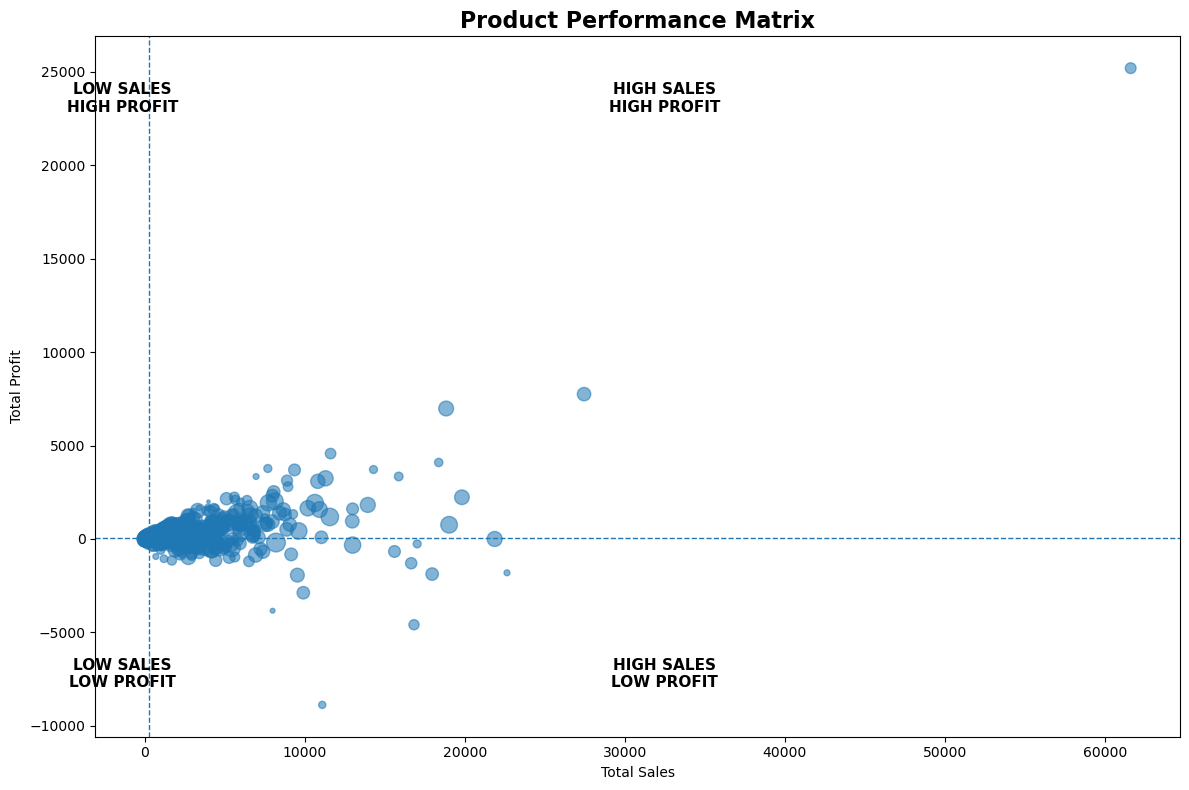

In [51]:
plt.figure(figsize=(12, 8))

# Scatter plot
plt.scatter(
    product_performance["Sales"],
    product_performance["Profit"],
    s=product_performance["Quantity"] * 3,
    alpha=0.55
)

# Median reference lines
plt.axvline(
    sales_median,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    profit_median,
    linestyle="--",
    linewidth=1
)

# Axis limits
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

# Quadrant labels
plt.text(
    x_min + (sales_median - x_min) * 0.5,
    y_max * 0.85,
    "LOW SALES\nHIGH PROFIT",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

plt.text(
    sales_median + (x_max - sales_median) * 0.5,
    y_max * 0.85,
    "HIGH SALES\nHIGH PROFIT",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

plt.text(
    x_min + (sales_median - x_min) * 0.5,
    y_min * 0.75,
    "LOW SALES\nLOW PROFIT",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

plt.text(
    sales_median + (x_max - sales_median) * 0.5,
    y_min * 0.75,
    "HIGH SALES\nLOW PROFIT",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Total Sales")
plt.ylabel("Total Profit")

plt.title(
    "Product Performance Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

# Save 
plt.savefig(
    "visualizations/product_performance_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Product Performance Matrix: Products are segmented by median sales and profit to identify commercially important product groups. Bubble size represents quantity sold. High-sales/high-profit products represent the strongest performers, while high-sales/low-profit products warrant further investigation into pricing, discounts, and costs. Loss-making products are particularly important because they generate revenue without contributing positively to profitability.

# Executive Summary

## Key Findings

### 1. Regional performance
The West generated the highest total sales, followed by the East.
However, revenue alone does not determine which region is most
attractive because profitability must also be considered.

### 2. Customer concentration
A relatively small number of customers contribute disproportionately
to sales, creating opportunities for targeted retention and account
management.

### 3. Product performance
The highest-volume products are not necessarily the products
generating the highest profit.

### 4. Discounting
Further analysis is required to determine whether higher discount
levels are associated with weaker profit margins.

### 5. Profitability risk
Products generating significant sales but low or negative margins
should be prioritized for pricing, discount and cost review.

# Business Recommendations

1. Review high-sales / low-profit products for pricing and discount
   strategy.

2. Investigate regional profitability rather than using sales alone
   to allocate resources.

3. Identify high-value customers for targeted retention strategies.

4. Review discount policies where high discounts coincide with
   deteriorating margins.

5. Monitor sales and profit simultaneously rather than treating
   revenue growth as the sole indicator of business performance.

In [52]:
# Export the cleaned dataset for Tableau
df.to_csv("superstore_tableau.csv", index=False)

# Creating an excel version
df.to_excel("superstore_tableau.xlsx", index=False)

print("Tableau files created successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df.columns.tolist())

Tableau files created successfully.
Rows: 9994
Columns: 25
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Year_Month', 'Discount_Band']
